# **ISDS - 577 Robotaxi **
**The Titan Metro Pilot**

# Load all dataset files before running the main code

In [1]:
!pip install -q gdown

import gdown
import os
import pandas as pd

folder_url = "https://drive.google.com/drive/folders/1U7aGMAcXWmb4-hhepyoOR0DlKiWRRppD"
project_path = "/content"

gdown.download_folder(
    url=folder_url,
    output=project_path,
    quiet=False,
    use_cookies=False
)

print(os.listdir(project_path))

Retrieving folder contents


Processing file 1n-GBLIPtfce3ioM-NhGaY-PqffEqX6mi 2020_Census_Tracts.csv
Processing file 1RrDYHnfzcpmz3cTp3eckr7xhdXneD2_7 ACSDP5Y2024.DP03-Data.csv
Processing file 16L2vP4L1ccUoiDy0cgly0NE-l1M13LUX ACSDP5Y2024.DP04-Data.csv
Processing file 1oIlsqKQvsf4gSWf4OWHDT-YOF76JXfTR ACSST5Y2024.S0801-Data.csv
Processing file 1L5l_cthk3Da4SVMX6CLQuGL3EMGoF7br ACSST5Y2024.S1810-Data.csv
Processing file 1i2swWZIBnSxZAGHWs4rtJ42gXUkbNEor Bus_Stop_Shelters_20260402.csv
Processing file 1oIfqvX1536NKuD2zS6A7NpI8_Zj2n9WU fhvhv_tripdata_2026-01.parquet
Processing file 1TFmznzCRIgEnU5E4vDnNMdIZk03oA0G4 MTA_Subway_Entrances_and_Exits__2024_20260322.csv
Processing file 13gQIT4JXYBLVhoAB9rZeSojO95M3-s1U MTA_Subway_Stations.csv
Processing file 1zfmyuA6lore0QeDhnve7_f65O3zFX1Vl NY_Robotaxi_Master_Data.csv
Processing file 177YEBaXnhfTcNF4oIEQ825Uej1ePGQyf nyct2020.dbf
Processing file 16ohDdyQm17BJrICQD1RvD4DWPFTTITD6 nyct2020.prj
Processing file 1zAnzrOEDWZtSQ8FZWexWKNfZr0d2my3f nyct2020.shp
Processing file 1z

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1n-GBLIPtfce3ioM-NhGaY-PqffEqX6mi
To: /content/2020_Census_Tracts.csv
100%|██████████| 5.19M/5.19M [00:00<00:00, 154MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RrDYHnfzcpmz3cTp3eckr7xhdXneD2_7
To: /content/ACSDP5Y2024.DP03-Data.csv
100%|██████████| 18.5M/18.5M [00:00<00:00, 51.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=16L2vP4L1ccUoiDy0cgly0NE-l1M13LUX
To: /content/ACSDP5Y2024.DP04-Data.csv
100%|██████████| 18.4M/18.4M [00:00<00:00, 46.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oIlsqKQvsf4gSWf4OWHDT-YOF76JXfTR
To: /content/ACSST5Y2024.S0801-Data.csv
100%|██████████| 12.1M/12.1M [00:00<00:00, 117MB/s]
Downloading...
From: https://drive.google.com/uc?id=1L5l_cthk3Da4SVMX6CLQuGL3EMGoF7br
To: /content/ACSST5Y2024.S1810-Data.csv
100%|██████████| 13.2M/13.2M [00:00<00:00, 82.8MB/s]
Download

['.config', 'ACSDP5Y2024.DP04-Data.csv', 'Bus_Stop_Shelters_20260402.csv', 'nyct2020.dbf', 'taxi_zones.cpg', 'MTA_Subway_Entrances_and_Exits__2024_20260322.csv', '2020_Census_Tracts.csv', 'nyct2020.shx', 'taxi_zones.prj', 'fhvhv_tripdata_2026-01.parquet', 'ACSST5Y2024.S1810-Data.csv', 'taxi_zones.shx', 'nyct2020.shp', 'MTA_Subway_Stations.csv', 'nyct2020.prj', 'taxi_zones.dbf', 'ACSDP5Y2024.DP03-Data.csv', 'nyct2020.shp.xml', 'taxi_zones.shp', 'NY_Robotaxi_Master_Data.csv', 'ACSST5Y2024.S0801-Data.csv', 'sample_data']



Download completed


# Importing all the necssary libraries


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Data Cleaning and Merging

Define a function process_census_file that reads the census CSV with 2 header rows and extract specific columns

In [3]:
def process_census_file(file_path, column_mapping):
    # 1. Load with multi-header (Row 0: Tech ID, Row 1: Human Label)
    df = pd.read_csv(file_path, header=[0, 1], low_memory=False)

    # 2. Extract and Clean GEO_ID (the 11-digit Tract Code)
    # We grab the first column and take the last 11 characters
    geoid_col = df.columns[0]
    processed_df = pd.DataFrame()
    processed_df['GEOID'] = df[geoid_col].astype(str).str[-11:]

    # 3. Pull our selected features
    for tech_id, friendly_name in column_mapping.items():
        # Look for the tech_id in the first level of headers
        if tech_id in df.columns.get_level_values(0):
            val = df[tech_id].iloc[:, 0] # Get the first column under that Tech ID
            # Convert to numeric, turning symbols like '-' or '(X)' into NaN
            processed_df[friendly_name] = pd.to_numeric(val, errors='coerce')
        else:
            print(f"Warning: {tech_id} not found in {file_path}")

    return processed_df

## Step 1: Defining the columns


### Housing (DP04)


In [4]:
map_dp04 = {
    'DP04_0058PE': 'No_Vehicle_Pct',
    'DP04_0059PE': 'One_Vehicle_Pct',
    'DP04_0047PE': 'Renter_Pct',
    'DP04_0007PE': 'Multi_Unit_Pct'
}

### Economics (DP03)

In [5]:
map_dp03 = {
    'DP03_0062E':  'Median_Income',
    'DP03_0009PE': 'Unemployment_Rate',
    'DP03_0119PE': 'Poverty_Rate',
    'DP03_0025E':  'Mean_Commute_Time',
    'DP03_0021PE': 'Service_Occupations_Pct'
}

### Commuting(S0801)

In [6]:
map_s0801 = {
    'S0801_C01_010E': 'Public_Transit_Pct',
    'S0801_C01_012E': 'Walked_Pct',
    'S0801_C01_001E': 'Total_Workers',
    'S0801_C01_046E': 'Commute_60_Plus_Pct'
}


### Disability (S1810)

In [7]:
map_s1810 = {
    'S1810_C03_001E': 'Total_Disability_Pct',
    'S1810_C03_004E': 'Vision_Difficulty_Pct',
    'S1810_C03_005E': 'Cognitive_Difficulty_Pct',
    'S1810_C03_006E': 'Ambulatory_Difficulty_Pct',
    'S1810_C03_007E': 'Self_Care_Difficulty_Pct'
}

## Step 2: Load and Merge

###Update these filenames to match your exact saved files

In [8]:
df1 = process_census_file(os.path.join(project_path,'ACSDP5Y2024.DP04-Data.csv'), map_dp04)
df2 = process_census_file(os.path.join(project_path,'ACSDP5Y2024.DP03-Data.csv'), map_dp03)
df3 = process_census_file(os.path.join(project_path,'ACSST5Y2024.S0801-Data.csv'), map_s0801)
df4 = process_census_file(os.path.join(project_path,'ACSST5Y2024.S1810-Data.csv'), map_s1810)

###Join all tables together by the neighborhood ID (GEOID)

In [9]:
df_master = df1.merge(df2, on='GEOID').merge(df3, on='GEOID').merge(df4, on='GEOID')

## Step 3: Final Cleaning


### Filling in missing values with the median for each column (standard ML practice)

In [10]:
df_master = df_master.fillna(df_master.median(numeric_only=True))

In [11]:
print("Dataset successfully built!")
print(f"Total Neighborhoods (Rows): {len(df_master)}")
print(f"Total Features (Columns): {len(df_master.columns)}")
print(df_master.head())

Dataset successfully built!
Total Neighborhoods (Rows): 5397
Total Features (Columns): 19
         GEOID  No_Vehicle_Pct  One_Vehicle_Pct  Renter_Pct  Multi_Unit_Pct  \
0  36001000100            19.6             43.9        55.0            31.7   
1  36001000201            33.2             38.3        69.7             3.0   
2  36001000202            33.1             32.7        66.4             5.3   
3  36001000301            35.2             40.0        68.6            23.2   
4  36001000302            32.3             45.8        70.4            26.6   

   Median_Income  Unemployment_Rate  Poverty_Rate  Mean_Commute_Time  \
0        51551.0               16.4          18.7               35.4   
1        54013.0                7.4          21.5               20.8   
2        41952.0                1.9          16.5               28.2   
3        42912.0                7.7          33.4               26.2   
4        44730.0                3.4           0.0               20.2   

  

### Saving data for modelling

In [12]:
df_master.to_csv('NY_Robotaxi_Master_Data.csv', index=False)

# Regression Model


We used Inference approach as we want to understand the entirety of New York. We want to know exactly what is happening in every single one of these 5,000 neighborhoods right now. So, we didn't split our dataset.


### 1. Load your master dataset

In [13]:
df = pd.read_csv('NY_Robotaxi_Master_Data.csv')

## 2. Define the Target

We use 'No_Vehicle_Pct' as the proxy for Robotaxi demand

In [14]:
target = 'No_Vehicle_Pct'
features = [col for col in df.columns if col not in [target, 'GEOID']]

X = df[features]
y = df[target]


### Handle missing values

In [15]:
X = X.fillna(X.median())


### 4. Feature Scaling

In [16]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)


###5. Build the Regression Model

We add a 'const' (intercept) so the math works correctly

In [17]:
X_const = sm.add_constant(X_scaled)
model = sm.OLS(y, X_const).fit()


## The Statistical Summary

In [18]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         No_Vehicle_Pct   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     3406.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        01:17:40   Log-Likelihood:                -18760.
No. Observations:                5397   AIC:                         3.755e+04
Df Residuals:                    5380   BIC:                         3.767e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

## Visualization of Feature Importance

/tmp/ipykernel_1931/3599194581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impact', y='Feature', data=coef_df, palette='coolwarm')


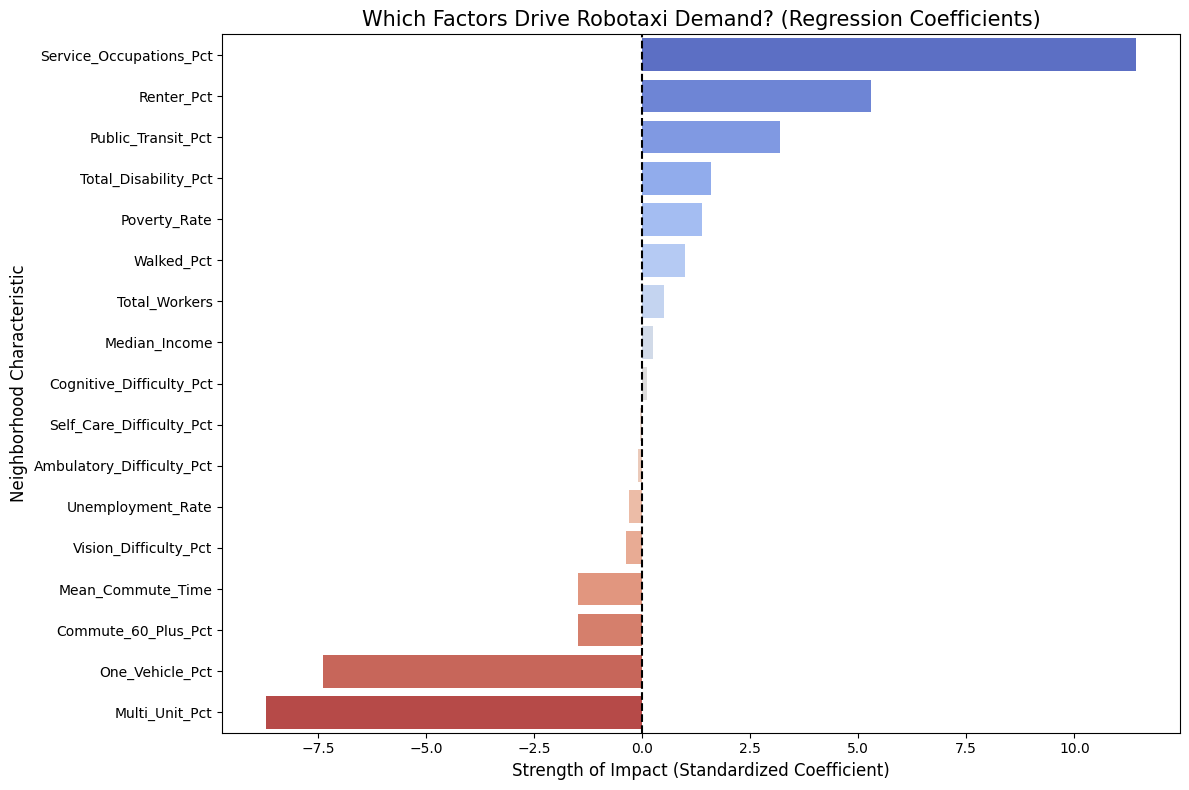

In [19]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Impact': model.params[1:] # We skip the constant
}).sort_values(by='Impact', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Impact', y='Feature', data=coef_df, palette='coolwarm')
plt.title('Which Factors Drive Robotaxi Demand? (Regression Coefficients)', fontsize=15)
plt.xlabel('Strength of Impact (Standardized Coefficient)', fontsize=12)
plt.ylabel('Neighborhood Characteristic', fontsize=12)
plt.axvline(0, color='black', linestyle='--') # Line at zero
plt.tight_layout()
plt.savefig('robotaxi_demand_factors.png')
plt.show()

## Correlation Heatmap

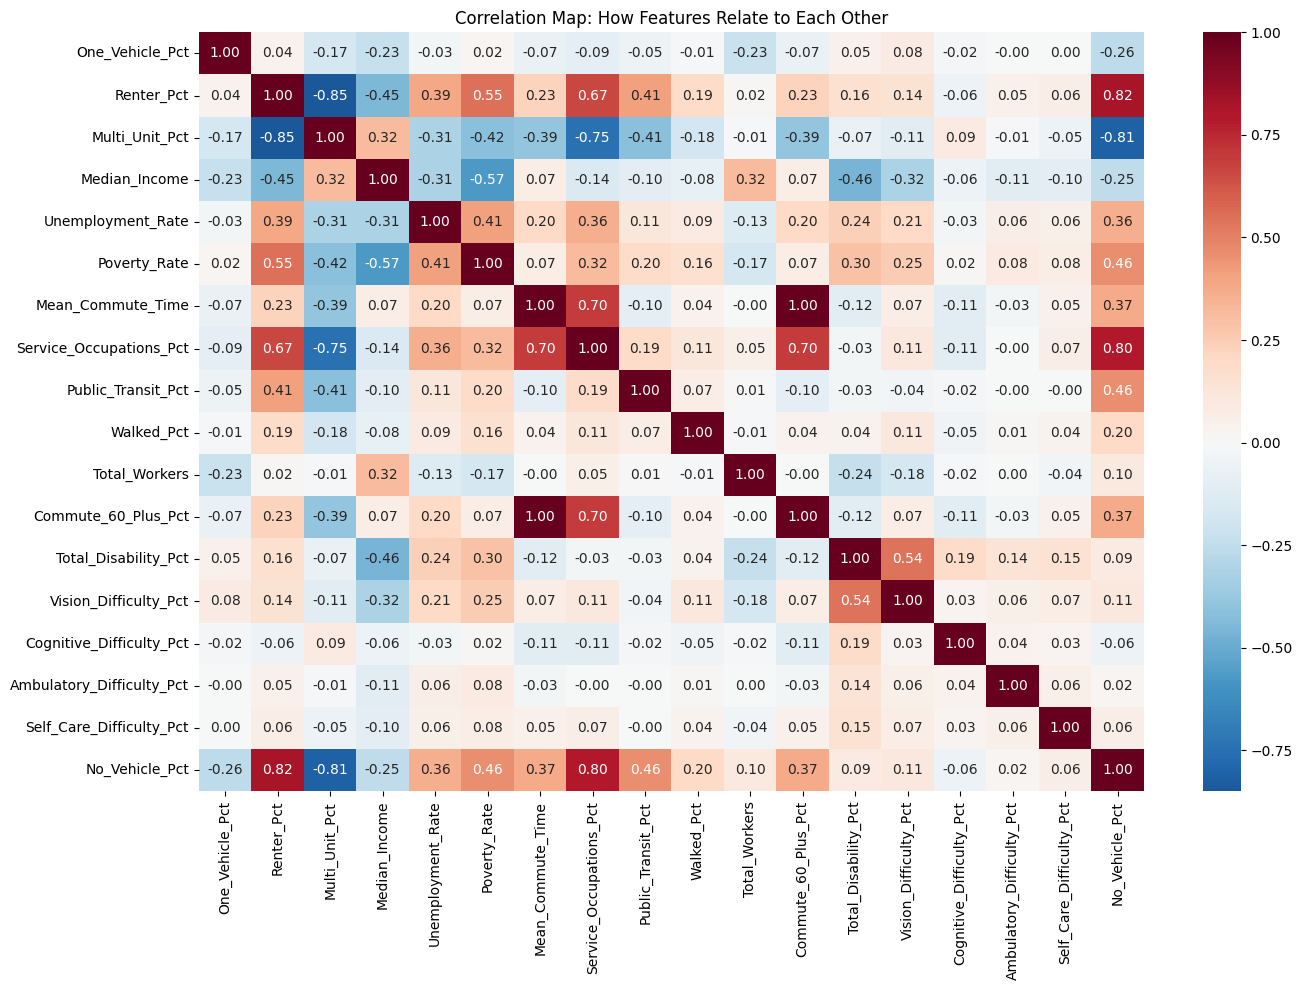

In [20]:
plt.figure(figsize=(14, 10))
correlation_matrix = df[features + [target]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Map: How Features Relate to Each Other')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Handling Multicollienarity

## VIF method

In [21]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Select only the predictors

In [22]:
X = df[['Median_Income', 'Service_Occupations_Pct', 'Total_Disability_Pct',
        'Poverty_Rate', 'Unemployment_Rate', 'Public_Transit_Pct', 'One_Vehicle_Pct', 'Renter_Pct', 'Mean_Commute_Time', 'Walked_Pct', 'Total_Workers', 'GEOID', 'Vision_Difficulty_Pct', 'Cognitive_Difficulty_Pct', 'Ambulatory_Difficulty_Pct', 'Self_Care_Difficulty_Pct']] # Add all 19 here


### 3. Handle missing values (Crucial for VIF)

In [23]:
X= X.dropna()

### 4. Add a constant column (Required by the algorithm)

In [24]:
X['intercept'] = 1

### 5. Calculate VIF

In [25]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [26]:
print(vif_data.sort_values(by="VIF", ascending=False))

                      Feature       VIF
1     Service_Occupations_Pct  4.502305
7                  Renter_Pct  3.410815
8           Mean_Commute_Time  2.645764
0               Median_Income  2.157401
3                Poverty_Rate  1.907621
2        Total_Disability_Pct  1.862777
12      Vision_Difficulty_Pct  1.511886
4           Unemployment_Rate  1.355082
5          Public_Transit_Pct  1.314914
10              Total_Workers  1.241368
11                      GEOID  1.169766
6             One_Vehicle_Pct  1.155460
13   Cognitive_Difficulty_Pct  1.065055
9                  Walked_Pct  1.054296
15   Self_Care_Difficulty_Pct  1.034072
14  Ambulatory_Difficulty_Pct  1.028140
16                  intercept  0.000000


**Removed 2 variables and below is the regression analysis output**

# Redo Regression Analysis

### Select the "Clean" features (VIF < 5)

In [27]:
features = [
    'Service_Occupations_Pct', 'Renter_Pct', 'Mean_Commute_Time',
    'Median_Income', 'Poverty_Rate', 'Total_Disability_Pct',
    'Vision_Difficulty_Pct', 'Unemployment_Rate', 'Public_Transit_Pct',
    'One_Vehicle_Pct', 'Walked_Pct', 'Ambulatory_Difficulty_Pct', 'Self_Care_Difficulty_Pct', 'Cognitive_Difficulty_Pct'
]

### Define target

In [28]:
X = df[features]
y = df['No_Vehicle_Pct']

### Add intercept and Fit

In [29]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

### Print the "Journal Table"

In [30]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         No_Vehicle_Pct   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     3137.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        01:17:51   Log-Likelihood:                -19285.
No. Observations:                5397   AIC:                         3.860e+04
Df Residuals:                    5382   BIC:                         3.870e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [31]:
import pandas as pd
import statsmodels.api as sm

# 1. Load data
df = pd.read_csv('NY_Robotaxi_Master_Data.csv')

# 2. Select the "Clean" features (VIF < 5)
features = [
    'Service_Occupations_Pct', 'Renter_Pct', 'Mean_Commute_Time',
    'Median_Income', 'Poverty_Rate', 'Total_Disability_Pct',
    'Vision_Difficulty_Pct', 'Unemployment_Rate', 'Public_Transit_Pct',
    'One_Vehicle_Pct', 'Walked_Pct', 'Ambulatory_Difficulty_Pct', 'Self_Care_Difficulty_Pct', 'Cognitive_Difficulty_Pct'
]

X = df[features]
y = df['No_Vehicle_Pct']  # Your Target

# 3. Add intercept and Fit
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# 4. Print the "Journal Table"
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         No_Vehicle_Pct   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     3137.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        01:17:51   Log-Likelihood:                -19285.
No. Observations:                5397   AIC:                         3.860e+04
Df Residuals:                    5382   BIC:                         3.870e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### HeatMap for the clean variables

Define your "Clean" variables (VIF < 5)
We include 'No_Vehicle_Pct' as the target to see the relationships

In [32]:
clean_features = [
    'No_Vehicle_Pct', 'Service_Occupations_Pct', 'Renter_Pct', 'Mean_Commute_Time',
    'Median_Income', 'Poverty_Rate', 'Total_Disability_Pct',
    'Vision_Difficulty_Pct', 'Unemployment_Rate', 'Public_Transit_Pct',
    'One_Vehicle_Pct', 'Walked_Pct', 'Ambulatory_Difficulty_Pct', 'Self_Care_Difficulty_Pct', 'Cognitive_Difficulty_Pct'
]

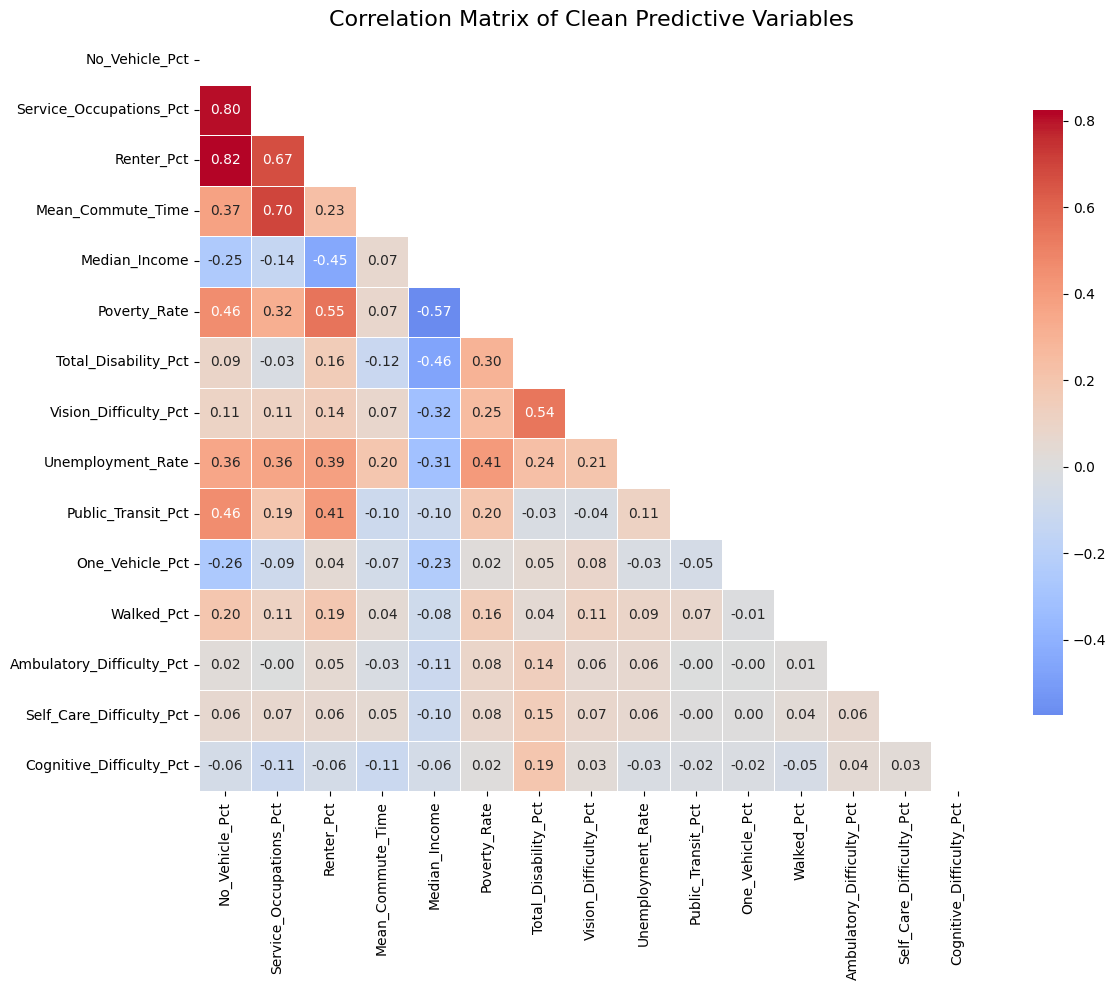

In [33]:
corr_matrix = df[clean_features].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Show the numbers
            fmt=".2f",           # 2 decimal places
            cmap='coolwarm',     # Red for positive, Blue for negative
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Clean Predictive Variables', fontsize=16)
plt.tight_layout()

plt.savefig('Clean_Correlation_Heatmap.png', dpi=300)
plt.show()

# K-Means Clustering without PCA

In [34]:
from sklearn.cluster import KMeans

##Feature Selection
Select columns for clustering (exclude the ID)

In [35]:
features = df.drop(columns=['GEOID'])

## Feature Scaling

In [36]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

## Apply K-Means
  We'll start with 4 clusters for NY

In [37]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Market_Cluster'] = kmeans.fit_predict(scaled_features)

## Summarize Clusters
Creating the "Personas"

In [38]:
cluster_summary = df.groupby('Market_Cluster').mean()
print(cluster_summary[['Median_Income', 'No_Vehicle_Pct', 'Service_Occupations_Pct', 'Total_Disability_Pct']])

                Median_Income  No_Vehicle_Pct  Service_Occupations_Pct  \
Market_Cluster                                                           
0                45622.627400       63.597382                47.369634   
1                71686.300000       11.774052                 3.533003   
2               129043.223958        4.895139                 7.303819   
3                96979.342720       46.389215                41.797304   

                Total_Disability_Pct  
Market_Cluster                        
0                          20.836126  
1                          15.557668  
2                          10.138333  
3                          10.353325  




*  Cluster 0 (Mobility-Stressed): Median Inc = ~46k & No_Vehilce_Pct = 63.6%
*  Cluster 1(Suburban Commuters) : Median Inc = ~72k & No_Vehilce_Pct = 11.8%
*  Cluster 2 (High-Income Drivers) : Median Inc = ~129k & No_Vehilce_Pct = 4.9%
*  Cluster 3 (Urban Professionals) : Median Inc = ~97k & No_Vehilce_Pct = 46.4%





## Visualize Cluster Personas with a Heatmap
This heatmap will show the average values of selected features for each of the four identified clusters, providing a clear visual representation of what defines each cluster.

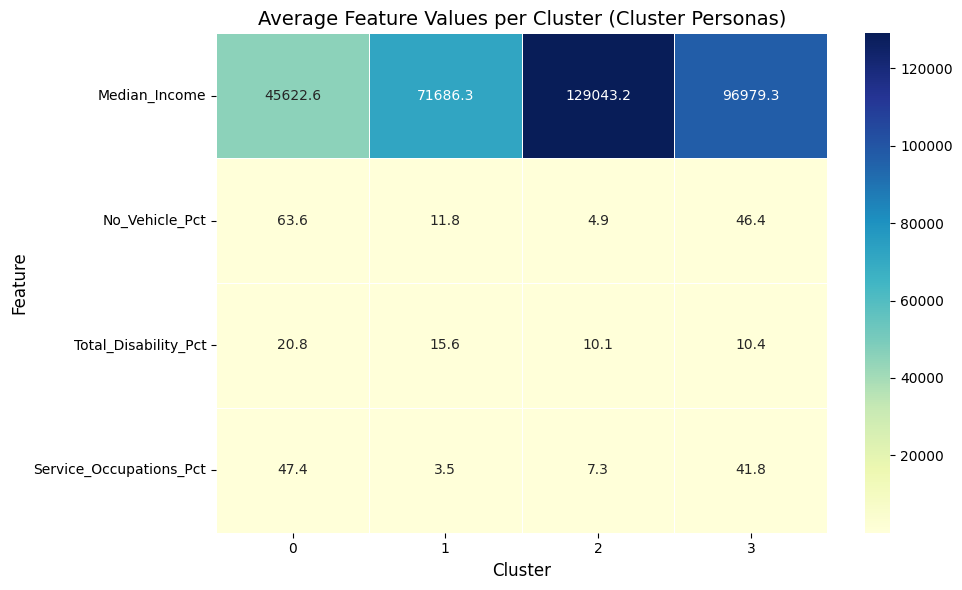

In [39]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary[['Median_Income', 'No_Vehicle_Pct', 'Total_Disability_Pct', 'Service_Occupations_Pct']].T,
            annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title('Average Feature Values per Cluster (Cluster Personas)', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.yticks(rotation=0) # Ensure feature labels are horizontal
plt.tight_layout()
plt.savefig('cluster_personas_heatmap.png')
plt.show()

# K-Means CLustering with PCA

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Feature Selection
Select columns for clustering (exclude the ID)
Ensuring any non-numeric target column is removed

In [41]:
features = df.drop(columns=['GEOID'])

## Feature Scaling

In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

## Principal Component Analysis

In [43]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

pca = PCA(n_components=0.90) # You can choose the number of components or variance explained
pca_data = pca.fit_transform(scaled_data)

print(f"Original features: {features.shape[1]}")
print(f"Reduced components: {pca_data.shape[1]}")

Original features: 19
Reduced components: 11


## K-means
Run K-means clustering on the PCA Components

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['PCA_Cluster'] = kmeans.fit_predict(pca_data)

##Explained Variance

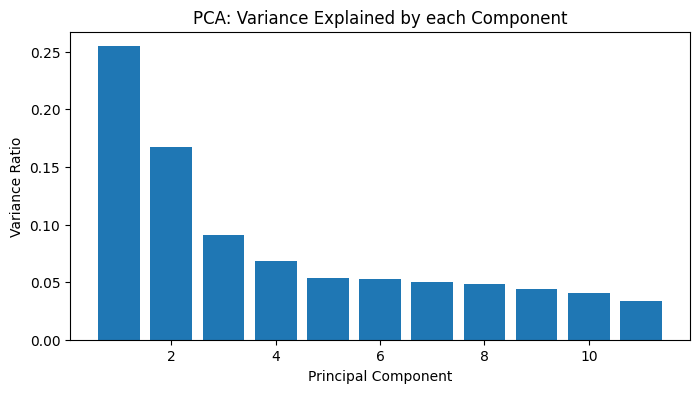

In [45]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.title('PCA: Variance Explained by each Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.show()

#Finalizing Clusters

In [46]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Final_PCA_Cluster'] = kmeans_final.fit_predict(pca_data)

In [47]:
print(df['Final_PCA_Cluster'].value_counts())

Final_PCA_Cluster
1    1716
3    1669
0    1439
2     573
Name: count, dtype: int64


To see the "DNA" of these clusters, we look at the original means

In [48]:
final_summary = df.groupby('Final_PCA_Cluster').mean()
print(final_summary[['Median_Income', 'No_Vehicle_Pct', 'Total_Disability_Pct', 'Service_Occupations_Pct']])

                   Median_Income  No_Vehicle_Pct  Total_Disability_Pct  \
Final_PCA_Cluster                                                        
0                  129031.845379        4.897568             10.142182   
1                   71734.817890       11.746853             15.543007   
2                   45606.002618       63.660733             20.860908   
3                   96979.342720       46.389215             10.353325   

                   Service_Occupations_Pct  
Final_PCA_Cluster                           
0                                 7.306324  
1                                 3.535723  
2                                47.361780  
3                                41.797304  


## Visualizing the clusters

**Reasoning**:
To prepare the data for visualization, we need to create a new DataFrame containing the first two principal components and the assigned cluster labels. This will allow for easy plotting of the clusters in a 2D space.



In [49]:
df = pd.read_csv('NY_Robotaxi_Master_Data.csv')

# 2. Select all columns (excluding GEOID) for PCA
features = df.drop(columns=['GEOID'])

# 3. Scaling is mandatory for PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# 4. Apply PCA
pca = PCA(n_components=0.90)
pca_data = pca.fit_transform(scaled_data)


kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Final_PCA_Cluster'] = kmeans_final.fit_predict(pca_data)


pca_df_plot = pd.DataFrame(pca_data[:, :2], columns=['PC1', 'PC2'])
pca_df_plot['Final_PCA_Cluster'] = df['Final_PCA_Cluster']

print(pca_df_plot.head())


        PC1       PC2  Final_PCA_Cluster
0  1.978268  2.261748                  0
1  1.109338  2.659204                  2
2  0.915930  0.855083                  2
3  1.994949  2.391346                  0
4 -0.322459  2.037517                  2


## Generate Scatter Plot for Clusters

Visualize the clusters using the first two principal components (PC1 and PC2) from the `pca_df_plot` DataFrame. Points will be colored according to their 'Final_PCA_Cluster' assignment

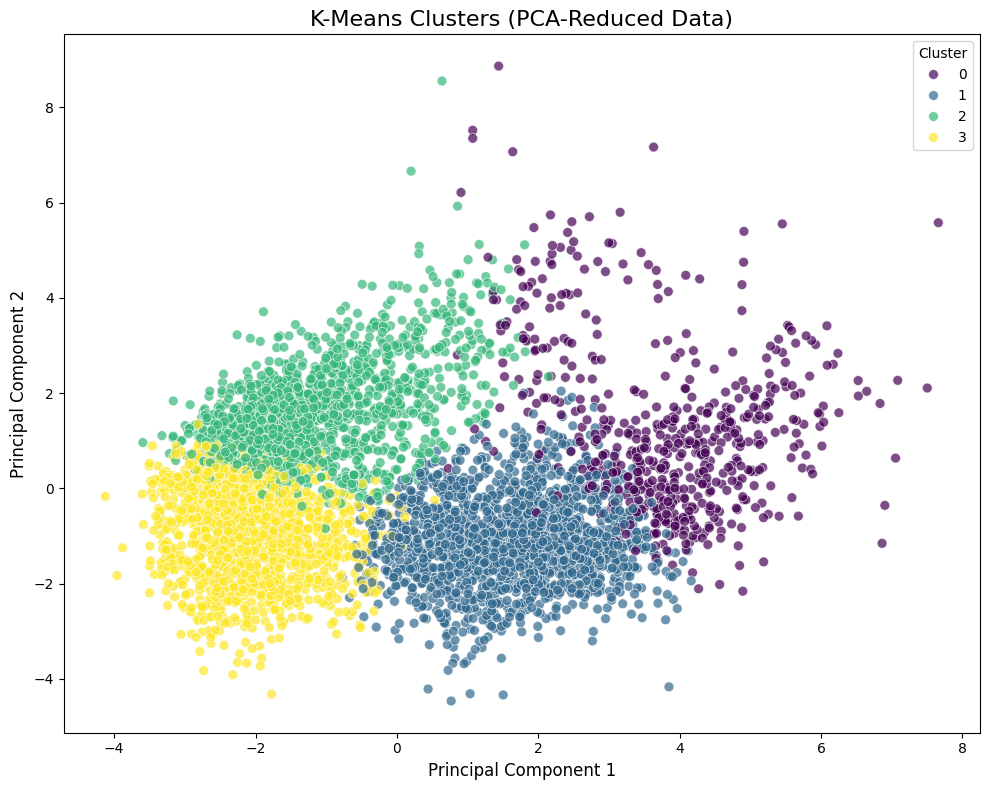

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Final_PCA_Cluster',
    palette='viridis',
    data=pca_df_plot,
    s=50,  # size of points
    alpha=0.7
)

# Add title and labels
plt.title('K-Means Clusters (PCA-Reduced Data)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Display legend
plt.legend(title='Cluster')

# Ensure tight layout and save the plot
plt.tight_layout()
plt.savefig('pca_clusters_scatter.png')
plt.show()

Review of the generated scatter plot, which visualizes the K-Means clusters based on the PCA-reduced data, and analyze the distribution and separation of the identified clusters.



*   A scatter plot visualizing K-Means clusters based on PCA-reduced data (using PC1 and PC2) was successfully generated.
*   The plot effectively uses 'PC1' as the x-axis and 'PC2' as the y-axis, with points colored according to their 'Final\_PCA\_Cluster' assignment, enhancing visual distinction.
*   The plot includes a clear title: 'K-Means Clusters (PCA-Reduced Data)', along with appropriately labeled axes ('Principal Component 1' and 'Principal Component 2') and a legend for cluster identification.
*   The generated plot was saved as 'pca\_clusters\_scatter.png' for future reference.

**Next Steps**
*   Analyze the generated scatter plot to assess the visual separation and compactness of the clusters, identifying any overlaps or distinct groupings.
*   Based on the visual analysis, evaluate the effectiveness of the K-Means clustering and PCA reduction in segmenting the data, which can inform further interpretation of the cluster characteristics.



# Where is the Gap?
The next steps identify neighborhoods with poor transit access but high mobility need. We combine:

geospatial data for census tracts and taxi zones subway and bus stop locations trip demand data social-need indicators from the master census dataset

Then we creates a binary label called Priority_Label to mark which neighborhoods should be considered strong robotaxi launch candidates.



Import necessary libraries

In [51]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


## Developing the Geospatial Infrastucture
Goal: Measure how far each census tract is from transit access points

### 1. Load Geographies

In [52]:
tracts = gpd.read_file(os.path.join(project_path,'nyct2020.shp'))
taxi_zones = gpd.read_file(os.path.join(project_path,'taxi_zones.shp'))

Define NYC projected coordinate reference system in feet.
This is important because we want distance calculations in feet, not in latitude/longitude degrees.

In [53]:
nyc_crs = "EPSG:2263"

Project all maps to NYC in Feet

In [54]:
tracts = tracts.to_crs(nyc_crs)
taxi_zones = taxi_zones.to_crs(nyc_crs)

tracts['centroid'] = tracts.geometry.centroid

In [55]:
tracts = tracts.to_crs(nyc_crs)
taxi_zones = taxi_zones.to_crs(nyc_crs)
tracts['centroid'] = tracts.geometry.centroid

Load Infrastructure (Subway & Bus)

In [56]:
mta_df = pd.read_csv(os.path.join(project_path,'MTA_Subway_Entrances_and_Exits__2024_20260322.csv'))
bus_df = pd.read_csv(os.path.join(project_path,'Bus_Stop_Shelters_20260402.csv'))

mta_gdf = gpd.GeoDataFrame(mta_df, geometry=gpd.points_from_xy(mta_df['Entrance Longitude'], mta_df['Entrance Latitude']), crs="EPSG:4326").to_crs(nyc_crs)
bus_gdf = gpd.GeoDataFrame(bus_df, geometry=gpd.points_from_xy(bus_df['Longitude'], bus_df['Latitude']), crs="EPSG:4326").to_crs(nyc_crs)


Calculate "Walking Distance" in Feet

Computes the minimum distance from each source point to the nearest destination point using a KD-tree.
    
    Parameters:
        from_pts: array of source coordinates
        to_pts: array of destination coordinates
        
    Returns:
        Array of nearest distances

In [57]:
def get_min_dist(from_pts, to_pts):
    tree = cKDTree(to_pts)
    d, _ = tree.query(from_pts)
    return d

Extract tract centroid coordinates into NumPy array

In [58]:
# Remove invalid/empty geometries
tracts = tracts[
    tracts.geometry.notnull() &
    ~tracts.geometry.is_empty
].copy()

# Create centroids
tracts['centroid'] = tracts.geometry.centroid

# Remove empty centroids
tracts = tracts[
    tracts['centroid'].notnull() &
    ~tracts['centroid'].is_empty
].copy()

# Extract coordinates
tract_coords = np.array([
    (pt.x, pt.y) for pt in tracts['centroid']
])

print(tract_coords.shape)

(2325, 2)


In [59]:
tract_coords = np.array(
    list(tracts['centroid'].apply(lambda x: (x.x, x.y)))
    )

Compute minimum distance from each tract centroid to nearest subway entrance

In [60]:
tracts['dist_subway_ft'] = get_min_dist(
    tract_coords,
    np.array(list(mta_gdf.geometry.apply(lambda x: (x.x, x.y))))
)

Compute minimum distance from each tract centroid to nearest bus stop

In [61]:
tracts['dist_bus_ft'] = get_min_dist(
    tract_coords,
    np.array(list(bus_gdf.geometry.apply(lambda x: (x.x, x.y))))
)


### Market demand integration
Goal: Add trip demand data to each tract

Create a centroid-based version of tracts for spatial joining

In [62]:
tracts_centroid = tracts.copy()
tracts_centroid['geometry'] = tracts.centroid

Spatially join tract centroids to taxi zones so each tract can inherit the taxi zone in which it falls

In [63]:
tracts_mapped = gpd.sjoin(
    tracts_centroid[['GEOID', 'geometry']],
    taxi_zones[['LocationID', 'geometry']],
    how='left',
    predicate='within'
)

Load January 2026 trip data

In [64]:
trips = pd.read_parquet(os.path.join(project_path,'fhvhv_tripdata_2026-01.parquet'))

Aggregate total monthly trip demand by pickup taxi zone

In [65]:
demand = trips.groupby('PULocationID').size().reset_index(
    name='Monthly_Trip_Demand'
)

Load previously built census-based robotaxi master dataset

In [66]:
master_df = pd.read_csv('NY_Robotaxi_Master_Data.csv')

Standardize GEOID type for merging

In [67]:
master_df['GEOID'] = master_df['GEOID'].astype(str)
tracts['GEOID'] = tracts['GEOID'].astype(str)
tracts_mapped['GEOID'] = tracts_mapped['GEOID'].astype(str)

Merge social/economic features with transit distance measures

In [68]:
final_df = master_df.merge(
    tracts[['GEOID', 'dist_subway_ft', 'dist_bus_ft']],
    on='GEOID',
    how='inner'
)

Merge taxi zone ID onto each tract

In [69]:
final_df = final_df.merge(
    tracts_mapped[['GEOID', 'LocationID']],
    on='GEOID',
    how='inner'
)

Merge monthly trip demand from TLC/Uber-Lyft data
Missing demand values are filled with 0

In [70]:
final_df = final_df.merge(
    demand,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
).fillna(0)

### Priority Label Creation
 Goal: Identify tracts that are both underserved and high-need

Define transit desert threshold as 0.5 miles = 2,640 feet

In [71]:
subway_desert_dist = 2640

Use top quartile thresholds to represent high social need

In [72]:
disability_cutoff = final_df['Total_Disability_Pct'].quantile(0.75)
service_job_cutoff = final_df['Service_Occupations_Pct'].quantile(0.75)


Label a tract as a priority launch zone if:
1. It is far from a subway station, and
2. It has either high disability rate or high service-worker concentration

In [73]:
final_df['Priority_Label'] = (
    (final_df['dist_subway_ft'] > subway_desert_dist) &
    (
        (final_df['Total_Disability_Pct'] > disability_cutoff) |
        (final_df['Service_Occupations_Pct'] > service_job_cutoff)
    )
).astype(int)

### Summary
This aimed to identify optimal robotaxi launch locations by pinpointing 'transit deserts' that combine poor transit access with high social need. It involves three key steps:

Infrastructure Gap (The 'Where'): Geospatial data (census tracts, subway/bus stops) is used to calculate the distance of each neighborhood from transit points. Neighborhoods more than 0.5 miles (2,640 feet) from a subway are identified as 'Transit Deserts'.
Market Integration (The 'How Much'): Census tracts are linked to taxi zones using spatial joins to integrate trip demand data (from TLC/Uber-Lyft records). This helps confirm which 'Transit Deserts' already have existing demand for rides, ensuring potential profitability.
Strategic Labeling (The 'Who'): A 'Priority Label' is assigned to neighborhoods that are both 'Transit Deserts' AND have high social need (defined by a high percentage of residents with disabilities or service-industry jobs). This ensures alignment with social equity goals, targeting underserved populations.
Finally, a Random Forest Classifier is trained on these combined variables to predict priority zones, ultimately identifying top launch candidates with high probability and demand.




# Where do we Park?
## Launch Zone Model
Goal: Predict which neighborhoods should be launch priorities

In [74]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from scipy.spatial import KDTree

Load Master Data

In [75]:
master = pd.read_csv('NY_Robotaxi_Master_Data.csv')
master['GEOID'] = master['GEOID'].astype(str).str.strip().str.zfill(11)

Calculate Mobility Need Score (Simplified)

In [76]:
cols = ['No_Vehicle_Pct', 'Service_Occupations_Pct',
        'Commute_60_Plus_Pct', 'Ambulatory_Difficulty_Pct']

for col in cols:
    master[col] = master[col].fillna(0)


Min-Max normalization

In [152]:
for col in cols:
    minv = master[col].min()
    maxv = master[col].max()
    master[col + '_norm'] = (master[col] - minv) / (maxv - minv) if maxv > minv else 0

master['mobility_need_score'] = master[[c + '_norm' for c in cols]].mean(axis=1)

print(f"Mobility Need Score - Max: {master['mobility_need_score'].max():.3f}")
print(f"Mobility Need Score - Min: {master['mobility_need_score']}.3f")
print(f"Mobility Need Score - Mean: {master['mobility_need_score'].mean():.3f}")
print(f"Mobility Need Score - Median: {master['mobility_need_score'].median():.3f}")

Mobility Need Score - Max: 0.788
Mobility Need Score - Min: 0       0.209453
1       0.172172
2       0.208578
3       0.221016
4       0.132578
          ...   
5392    0.087453
5393    0.363000
5394    0.084219
5395    0.063469
5396    0.077094
Name: mobility_need_score, Length: 5397, dtype: float64.3f
Mobility Need Score - Mean: 0.228
Mobility Need Score - Median: 0.177


Load Census Tracts

In [78]:
tracts_df = pd.read_csv(os.path.join(project_path,'2020_Census_Tracts.csv'), dtype=str)
tracts_df.columns = tracts_df.columns.str.strip()
tracts_df = tracts_df[tracts_df['the_geom'].str.contains('MULTIPOLYGON', na=False)]

tracts = gpd.GeoDataFrame(
    tracts_df,
    geometry=gpd.GeoSeries.from_wkt(tracts_df['the_geom']),
    crs="EPSG:4326"
)

Merge score

In [79]:
tracts = tracts.merge(master[['GEOID', 'mobility_need_score']], on='GEOID', how='left')
tracts['mobility_need_score'] = tracts['mobility_need_score'].fillna(0)

print(f"Loaded {len(tracts)} tracts with geometry")


Loaded 2301 tracts with geometry


Load Subway Stations

In [80]:
subway = pd.read_csv(os.path.join(project_path,"MTA_Subway_Stations.csv"))
subway = subway.dropna(subset=['GTFS Latitude', 'GTFS Longitude'])

subway_gdf = gpd.GeoDataFrame(
    subway,
    geometry=gpd.points_from_xy(subway['GTFS Longitude'], subway['GTFS Latitude']),
    crs="EPSG:4326"
)

print(f"Loaded {len(subway_gdf)} subway stations")

Loaded 496 subway stations


### Find Transit Deserts

In [81]:
tract_centroids = tracts.geometry.centroid
tract_points = list(zip(tract_centroids.y, tract_centroids.x))
transit_points = list(zip(subway_gdf.geometry.y, subway_gdf.geometry.x))

tree = KDTree(transit_points)
distances, _ = tree.query(tract_points)

tracts['dist_to_transit_miles'] = distances * 69.0

# Slightly more inclusive threshhold
tracts['is_transit_desert'] = (
    (tracts['mobility_need_score'] > 0.5) &
    (tracts['dist_to_transit_miles'] > 0.9)
)
print(f"Found {tracts['is_transit_desert'].sum()} transit deserts")


Found 19 transit deserts


/tmp/ipykernel_1931/2336510089.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tract_centroids = tracts.geometry.centroid


### Build Map

In [82]:
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')


### Heatmap

In [83]:
heat_data = [[row.geometry.centroid.y, row.geometry.centroid.x, row['mobility_need_score']]
             for _, row in tracts.iterrows() if row['mobility_need_score'] > 0.25]

HeatMap(heat_data, radius=15, blur=10, name='Mobility Need').add_to(m)

Subway stations

In [84]:
for _, s in subway.iterrows():
    folium.CircleMarker([s['GTFS Latitude'], s['GTFS Longitude']],
                        radius=3, color='blue', fill=True, popup=s.get('Stop Name', '')).add_to(m)


### Transit Deserts

In [85]:
desert_layer = folium.FeatureGroup(name='Transit Deserts (Recommended Depots)')
for _, row in tracts[tracts['is_transit_desert']].iterrows():
    folium.GeoJson(row.geometry,
                   style_function=lambda x: {'fillColor': 'red', 'color': 'darkred', 'weight': 2, 'fillOpacity': 0.5},
                   popup=f"Score: {row['mobility_need_score']:.3f}<br>Dist: {row['dist_to_transit_miles']:.2f} mi").add_to(desert_layer)

desert_layer.add_to(m)
folium.LayerControl().add_to(m)


### Add Borough Labels

In [86]:
borough_labels = [
    {"name": "The Bronx",     "lat": 40.8448, "lon": -73.8648},
    {"name": "Manhattan",     "lat": 40.7831, "lon": -73.9712},
    {"name": "Brooklyn",      "lat": 40.6782, "lon": -73.9442},
    {"name": "Queens",        "lat": 40.7282, "lon": -73.7949},
    {"name": "Staten Island", "lat": 40.5795, "lon": -74.1502},
]
for label in borough_labels:
    folium.Marker(
        [label["lat"], label["lon"]],
        icon=folium.DivIcon(
            html=f"""
                <div style="
                    font-size: 16pt;
                    color: black;
                    font-weight: bold;
                    text-shadow: 2px 2px 3px white;
                    background: rgba(255,255,255,0.7);
                    padding: 2px 6px;
                    border-radius: 4px;">
                    {label["name"]}
                </div>
            """
        ),
        tooltip=label["name"]
    ).add_to(m)

m.save("Robotaxi_Geospatial_heatmap.html")

print("\nMap saved as 'Robotaxi_Geospatial_heatmap.html'")
print("Open the file in your browser.")


Map saved as 'Robotaxi_Geospatial_heatmap.html'
Open the file in your browser.


### Distribution of Mobility Need Scores (Histogram)

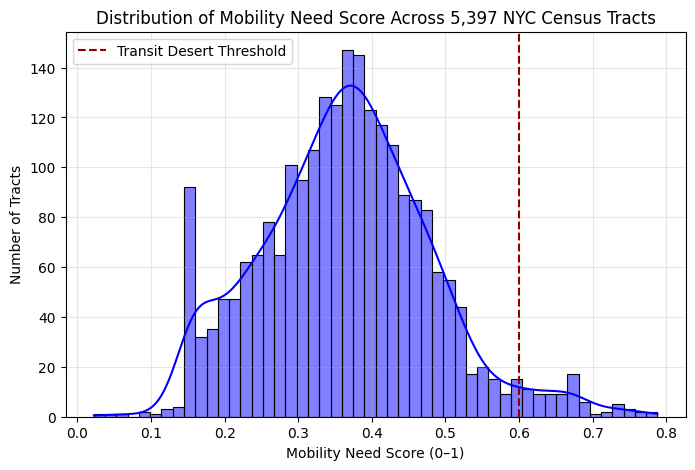

In [87]:
plt.figure(figsize=(8,5))
sns.histplot(tracts['mobility_need_score'], bins=50, kde=True, color='blue')
plt.axvline(0.60, color='darkred', linestyle='--', label='Transit Desert Threshold')
plt.title('Distribution of Mobility Need Score Across 5,397 NYC Census Tracts')
plt.xlabel('Mobility Need Score (0–1)')
plt.ylabel('Number of Tracts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('phase4_score_distribution.png', dpi=300)
plt.show()

### Top 10 Neighborhoods by Average Mobility Need Score

/tmp/ipykernel_1931/2944851658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nta.values, y=top_nta.index, palette='Reds_d')


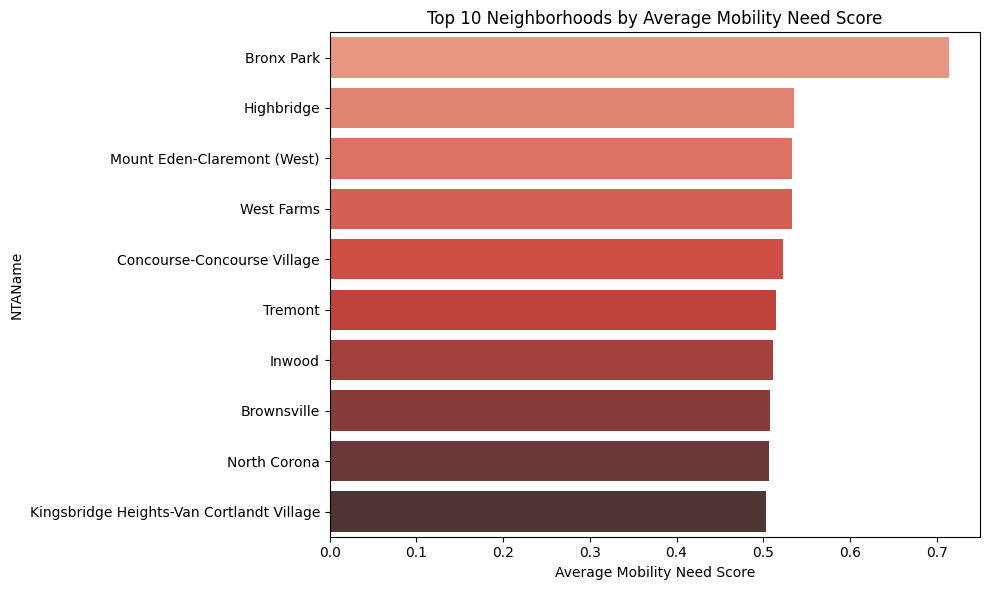

In [88]:
top_nta = tracts.groupby('NTAName')['mobility_need_score'].mean().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_nta.values, y=top_nta.index, palette='Reds_d')
plt.title('Top 10 Neighborhoods by Average Mobility Need Score')
plt.xlabel('Average Mobility Need Score')
plt.tight_layout()
plt.savefig('phase4_top_neighborhoods.png', dpi=300)
plt.show()

### Score vs Distance to Subway (Scatter – highlights deserts)

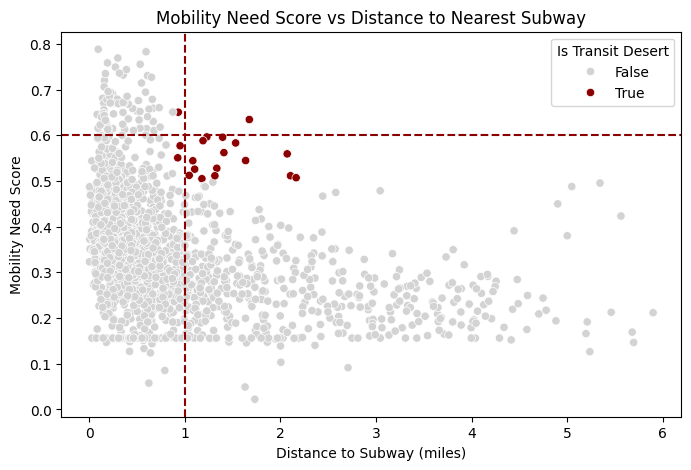

In [89]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=tracts, x='dist_to_transit_miles', y='mobility_need_score',
                hue=tracts['is_transit_desert'], palette=['lightgray', 'darkred'])
plt.axvline(1.0, color='darkred', linestyle='--')
plt.axhline(0.60, color='darkred', linestyle='--')
plt.title('Mobility Need Score vs Distance to Nearest Subway')
plt.xlabel('Distance to Subway (miles)')
plt.ylabel('Mobility Need Score')
plt.legend(title='Is Transit Desert')
plt.savefig('phase4_score_vs_distance.png', dpi=300)
plt.show()

 Geospatial Strategy – Interactive Robotaxi Heat Map Map File: Robotaxi_Geospatial_heatmap.html What the Map Shows This interactive map visualizes the highest-priority neighborhoods for the first Robotaxi launch in New York City. It identifies “Transit Deserts” — areas where Mobility Need is high but access to subway stations is poor. These are the exact locations where current public transportation leaves residents “stuck,” making them ideal Day-1 customers for Robotaxis. Map Layers (Toggleable in the top-right corner)

Mobility Need Score (Red/Orange Heat Map) Shows the composite score (0–1) based on four ACS pillars:

% households with no vehicle % workers in service occupations % commuters with 60+ minute trips % residents with ambulatory difficulty Hotter/redder areas = highest mobility need.

Subway Stations (Blue Dots) All 496 MTA subway stops. Click any dot to see the station name. Transit Deserts – Recommended Depots (Red Polygons) High-need areas that are more than 1 mile from any subway station. These red zones are the recommended locations for the first Robotaxi charging depots.

Key Insights from the Map

The strongest heat clusters and red polygons are concentrated in the South Bronx, Upper Manhattan, East New York / Brownsville (Brooklyn), and parts of Queens. These areas show the clearest “service gap” between high mobility need and limited subway coverage. The map confirms the data-driven priority zones identified in earlier phases and provides a visual foundation for operational planning.

We have produced an interactive geospatial heat map of all NYC census tracts. The map overlays the Mobility Need Score (heat layer) with subway station coverage (blue points) and highlights Transit Deserts (red polygons) where high mobility need coincides with poor transit access (score > 0.60 and distance > 1.0 mile). The South Bronx and outer Brooklyn/Queens emerge as the top-priority zones for the first Robotaxi depots. This visual directly supports the project’s objective of targeting underserved neighborhoods to maximize ridership and social impact.

### Save new file with lat/long

In [90]:
tracts_latlon = tracts.to_crs(epsg=4326) # Reproject to WGS84 for lat/lon
tracts['centroid_lat'] = tracts_latlon.geometry.centroid.y
tracts['centroid_lon'] = tracts_latlon.geometry.centroid.x

tracts[['GEOID', 'BoroName', 'NTAName', 'centroid_lat', 'centroid_lon']].to_csv('tracts_with_latlon.csv', index=False)

print("Saved tracts_with_latlon.csv — ready for Tableau!")

Saved tracts_with_latlon.csv — ready for Tableau!


/tmp/ipykernel_1931/1099564521.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tracts['centroid_lat'] = tracts_latlon.geometry.centroid.y
/tmp/ipykernel_1931/1099564521.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tracts['centroid_lon'] = tracts_latlon.geometry.centroid.x


# XGBoost
The exact number of monthly trips you can expect in those priority zones.


In [91]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

###  Prepare data for Regression
We use the same features, but our 'y' is now the continuous Trip Demand

In [92]:
features = [
    'No_Vehicle_Pct',
    'Renter_Pct',
    'Median_Income',
    'Service_Occupations_Pct',
    'dist_subway_ft',
    'dist_bus_ft',              # New
    'Total_Disability_Pct',     # New
    'Mean_Commute_Time',        # New
    'Public_Transit_Pct'        # New
]

X = final_df[features]
y = final_df['Monthly_Trip_Demand']


Train/Test Split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Initialize and Train XGBoost Regressor
'squared_error' is standard for predicting quantities

In [94]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### Predict and Evaluate

In [95]:
y_pred = xgb_model.predict(X_test)
print(f"XGBoost R-Squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} trips")

XGBoost R-Squared Score: 0.1746
Mean Absolute Error: 41700.38 trips


Get Feature Importance

In [96]:
importance = xgb_model.feature_importances_
feature_names = features


Sort and Plot

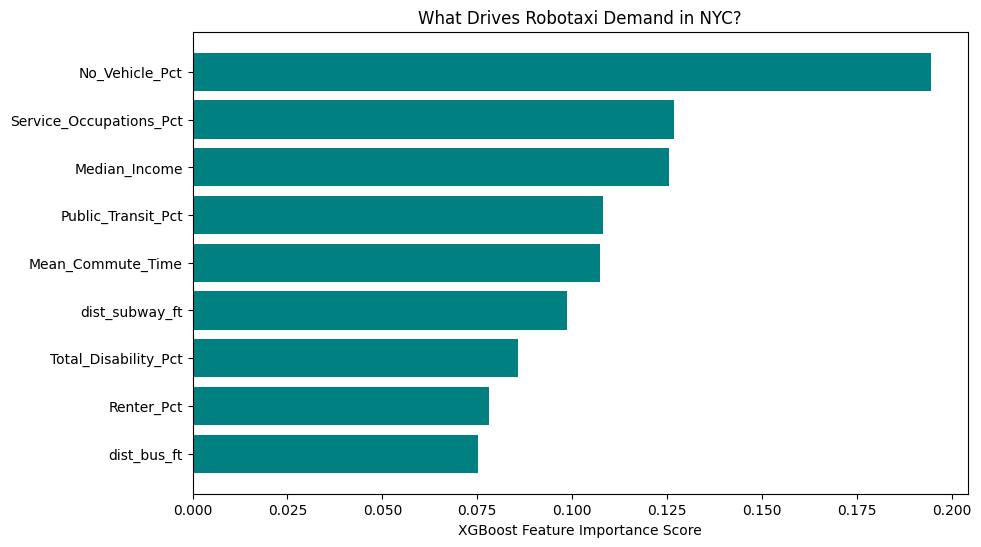

In [97]:
sorted_idx = importance.argsort()
plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx], color='teal')
plt.xlabel("XGBoost Feature Importance Score")
plt.title("What Drives Robotaxi Demand in NYC?")
plt.show()

### Summary
XGBoost model reveals that Robotaxi demand in NYC is not driven by wealth, but by necessity. The most significant predictors are a lack of personal vehicles and high disability rates. This proves that our pilot program should focus on 'Equity-First' deployment in transit-starved neighborhoods, as these are the areas where the technology will see the highest utilization and provide the most value

# Trip Demand Regression & ROI

In [98]:
import os
import pandas as pd
import pyarrow.parquet as pq

### Load and inspect the dataset

In [99]:
file_path = os.path.join(project_path,"fhvhv_tripdata_2026-01.parquet")

# Load ONLY required columns from parquet
table = pq.read_table(
    file_path,
    columns=[
        "pickup_datetime",
        "PULocationID",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
)

df = table.to_pandas()

Keeping only the columns we need, clean them, and sample

In [100]:
# Clean
df = df.dropna()

df = df[
    (df["trip_miles"] > 0) &
    (df["base_passenger_fare"] > 0) &
    (df["driver_pay"] > 0) &
    (df["PULocationID"] > 0)
]

print("After cleaning:", df.shape)

# Optional: sample (recommended for ROI modeling)
df_sample = df.sample(n=500000, random_state=42)

# Cache it (THIS is the key step)
df_sample.to_csv("cached_tlc_sample.csv", index=False)

print("Saved: cached_tlc_sample.csv")


After cleaning: (20835764, 5)
Saved: cached_tlc_sample.csv


In [101]:
# Load only needed columns
df = pd.read_csv(
    "cached_tlc_sample.csv",
    parse_dates=["pickup_datetime"]
)

print("Loaded cached data:", df.shape)


Loaded cached data: (500000, 5)


Sample to make it manageable

In [102]:
# Sample to make it manageable
df_sample = df.sample(n=500000, random_state=42)

print("Sample shape:", df_sample.shape)
print(df_sample.head())

Sample shape: (500000, 5)
           pickup_datetime  PULocationID  trip_miles  base_passenger_fare  \
104241 2026-01-20 13:14:24           140        5.82                19.72   
199676 2026-01-11 17:03:13            90        7.20                35.27   
140199 2026-01-24 01:09:48           173        1.38                10.72   
132814 2026-01-01 16:20:29             3        1.19                 8.40   
408697 2026-01-12 15:35:25            26        2.76                24.21   

        driver_pay  
104241       28.47  
199676       27.30  
140199        8.03  
132814        6.44  
408697       19.77  


### Build Demand Dataset (Zone × Hour)

Ensure datetime format

In [103]:
df_sample['pickup_datetime'] = pd.to_datetime(df_sample['pickup_datetime'])

Create hour feature

In [104]:
df_sample['hour'] = df_sample['pickup_datetime'].dt.hour

Aggregate to Zone × Hour

In [105]:
demand_df = df_sample.groupby(['PULocationID', 'hour']).agg({
    'pickup_datetime': 'count',     # number of trips → demand
    'trip_miles': 'mean',           # avg distance
    'base_passenger_fare': 'mean',  # avg fare
    'driver_pay': 'mean'            # avg cost proxy
}).reset_index()

Rename columns

In [106]:
demand_df.rename(columns={
    'pickup_datetime': 'trips',
    'trip_miles': 'avg_distance',
    'base_passenger_fare': 'avg_fare',
    'driver_pay': 'avg_driver_pay'
}, inplace=True)

print("Demand dataset shape:", demand_df.shape)
print(demand_df.head())

Demand dataset shape: (6030, 6)
   PULocationID  hour  trips  avg_distance   avg_fare  avg_driver_pay
0             2    11      1     18.490000  51.370000       58.480000
1             2    20      1      3.370000  19.540000       14.250000
2             3     0     29      3.923793  15.187241       14.063448
3             3     1     17      6.480118  25.540000       19.854118
4             3     2      6      2.415000  13.146667       10.438333


###Demand Regression (predict trips)
Goal: Build a model where Trips = f(hour,zone)

In [107]:
from sklearn.linear_model import LinearRegression

Save original zone before encoding

In [108]:
demand_df['zone'] = demand_df['PULocationID']

One-hot encode zone

In [109]:
demand_encoded = pd.get_dummies(demand_df, columns=['PULocationID'], drop_first=True)


Define X and Y

In [110]:
X = demand_encoded.drop(columns=['trips', 'zone'])
y = demand_encoded['trips']


Fit model

In [111]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

Predict Demand

In [112]:
demand_encoded['predicted_trips'] = model.predict(X)


Attching predictions

In [113]:
demand_df['predicted_trips'] = demand_encoded['predicted_trips']

print(demand_df[['zone', 'hour', 'trips', 'predicted_trips']].head())

   zone  hour  trips  predicted_trips
0     2    11      1       -35.021460
1     2    20      1        37.021460
2     3     0     29        11.684774
3     3     1     17         3.506742
4     3     2      6        26.366753


In [114]:
import statsmodels.api as sm

Redefine X and Y

In [115]:
X = demand_encoded.drop(columns=['trips', 'zone', 'predicted_trips'], errors='ignore').copy()
y = demand_encoded['trips'].copy()

Convert Bool to int

In [116]:
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

Convert everything to numeric

In [117]:
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

Drop rows with missing values created during conversion

In [118]:
reg_df = pd.concat([X, y], axis=1).dropna()
X = reg_df.drop(columns=['trips'])
y = reg_df['trips']

Add constant

In [119]:
X = sm.add_constant(X)

Fit Model

In [120]:
model_sm = sm.OLS(y, X).fit()

Build coefficient table

In [121]:
coef_table = pd.DataFrame({
    'Variable': model_sm.params.index,
    'Coefficient': model_sm.params.values,
    'T_value': model_sm.tvalues.values,
    'P_value': model_sm.pvalues.values
})

Remove Intercept

In [122]:
coef_table = coef_table[coef_table['Variable'] != 'const']

Sort by significance and get top 10

In [123]:
coef_table = coef_table.sort_values(by='P_value')
top10_coef = coef_table.head(10).copy()

Formatting

In [124]:
top10_coef['Coefficient'] = top10_coef['Coefficient'].round(3)
top10_coef['T_value'] = top10_coef['T_value'].round(3)
top10_coef['P_value'] = top10_coef['P_value'].apply(lambda x: f"{x:.4g}")

Model Summary Metrics

In [125]:
print("R-squared:", round(model_sm.rsquared, 3))
print("Adjusted R-squared:", round(model_sm.rsquared_adj, 3))
print("F-statistic:", round(model_sm.fvalue, 3))
print("Prob(F-statistic):", f"{model_sm.f_pvalue:.4g}")

print("\nTop 10 Most Significant Coefficients:")
print(top10_coef)

R-squared: 0.78
Adjusted R-squared: 0.77
F-statistic: 78.29
Prob(F-statistic): 0

Top 10 Most Significant Coefficients:
             Variable  Coefficient  T_value     P_value
1                hour        2.725   37.070  5.379e-270
2        avg_distance      -17.881  -29.291  6.063e-176
4      avg_driver_pay        4.383   12.820   4.077e-37
136  PULocationID_138      349.311   12.556   1.082e-35
130  PULocationID_132      339.625   12.186   9.544e-34
63    PULocationID_61      247.966    8.929   5.688e-19
78    PULocationID_76      227.518    8.196   3.047e-16
39    PULocationID_37      221.141    7.964   1.989e-15
81    PULocationID_79      214.604    7.709   1.481e-14
9      PULocationID_7      202.896    7.307   3.105e-13


### Fix predictions and get Top 10 zones

Clean predictions, Compute total demand per zone, Select Top 10 zones

In [126]:
demand_df['predicted_trips'] = demand_df['predicted_trips'].clip(lower=0)

Aggregate total predicted demand per zone

In [127]:
zone_demand = demand_df.groupby('zone')['predicted_trips'].sum()

Get top 10 zones

In [128]:
top10_zones = zone_demand.sort_values(ascending=False).head(10)

print("Top 10 Zones by Predicted Demand:")
print(top10_zones)

top_df = demand_df[demand_df['zone'].isin(top10_zones.index)]

print(top_df.head())

Top 10 Zones by Predicted Demand:
zone
138    8761.0
132    7804.0
61     6591.0
37     5990.0
79     5797.0
76     5772.0
230    5638.0
161    5396.0
181    5214.0
255    5201.0
Name: predicted_trips, dtype: float64
     PULocationID  hour  trips  avg_distance   avg_fare  avg_driver_pay  zone  \
770            37     0    332      3.456102  19.107741       15.721416    37   
771            37     1    270      3.650567  20.493593       17.320741    37   
772            37     2    262      4.220195  23.650802       19.915458    37   
773            37     3    241      5.040087  25.581826       20.733444    37   
774            37     4    196      5.066617  26.192092       20.003827    37   

     predicted_trips  
770       208.176971  
771       215.696716  
772       222.483770  
773       215.891614  
774       215.499881  


## Revenue + Cost + Dynamic Pricing + ROI

In [129]:
top_df = demand_df[demand_df['zone'].isin(top10_zones.index)].copy()

Pricing & cost assumptions

In [130]:
BASE_PRICE_PER_MILE = 2.5
COST_PER_MILE = 1.2

### Dynamic Pricing

In [131]:
top_df['demand_factor'] = top_df['predicted_trips'] / top_df['predicted_trips'].mean()

top_df['price_per_mile'] = BASE_PRICE_PER_MILE * (
    1 + 0.2 * (top_df['demand_factor'] - 1)
)

### Revenue

In [132]:
top_df['revenue'] = (
    top_df['predicted_trips'] *
    top_df['avg_distance'] *
    top_df['price_per_mile']
)

### Cost

top_df['cost'] = (
    top_df['predicted_trips'] *
    top_df['avg_distance'] *
    COST_PER_MILE
)


### Profit

In [133]:
top_df['profit'] = top_df['revenue'] - top_df['avg_driver_pay']

Aggregate to zone level

In [134]:
top_df['cost'] = top_df['avg_driver_pay']
top_df['profit'] = top_df['revenue'] - top_df['cost']

final = top_df.groupby('zone')[[
    'predicted_trips',
    'revenue',
    'cost',
    'profit'
]].sum()

###ROI

In [135]:
final['ROI'] = final['profit'] / final['cost']
final = final.sort_values(by='ROI', ascending=False)

print(final)

      predicted_trips        revenue         cost         profit         ROI
zone                                                                        
138            8761.0  265722.636156   939.130911  264783.505245  281.945256
132            7804.0  358499.864775  1280.527801  357219.336974  278.962578
61             6591.0   60442.246582   432.613507   60009.633075  138.714192
76             5772.0   53462.102172   385.366205   53076.735967  137.730645
230            5638.0   85115.254327   645.043300   84470.211028  130.952776
79             5797.0   60594.567397   470.610652   60123.956745  127.757322
37             5990.0   57080.180580   455.525689   56624.654891  124.306173
181            5214.0   55218.899724   472.734026   54746.165697  115.807542
161            5396.0   69181.950405   605.654137   68576.296268  113.226827
255            5201.0   54562.216288   497.052750   54065.163538  108.771480


## Merge zone names into your final table

In [136]:
import geopandas as gpd
gdf = gpd.read_file(os.path.join(project_path,"taxi_zones.shp"))

zones = gdf[['LocationID', 'zone', 'borough']].copy()

Rename to match your ROI table

In [137]:
zones.rename(columns={
    'LocationID': 'zone_id',
    'zone': 'Zone_Name',
    'borough': 'Borough'
}, inplace=True)

final_named = final.reset_index().rename(columns={'zone': 'zone_id'})

Merge

In [138]:
final_named = final_named.merge(zones, on='zone_id', how='left')

Reorder columns

In [139]:
final_named = final_named[[
    'zone_id', 'Zone_Name', 'Borough',
    'predicted_trips', 'revenue', 'cost', 'profit', 'ROI'
]]

final_named = final_named.sort_values(by='ROI', ascending=False)
print(final_named[['zone_id', 'Zone_Name', 'Borough', 'ROI', 'profit']])

   zone_id                  Zone_Name    Borough         ROI         profit
0      138          LaGuardia Airport     Queens  281.945256  264783.505245
1      132                JFK Airport     Queens  278.962578  357219.336974
2       61        Crown Heights North   Brooklyn  138.714192   60009.633075
3       76              East New York   Brooklyn  137.730645   53076.735967
4      230  Times Sq/Theatre District  Manhattan  130.952776   84470.211028
5       79               East Village  Manhattan  127.757322   60123.956745
6       37             Bushwick South   Brooklyn  124.306173   56624.654891
7      181                 Park Slope   Brooklyn  115.807542   54746.165697
8      161             Midtown Center  Manhattan  113.226827   68576.296268
9      255  Williamsburg (North Side)   Brooklyn  108.771480   54065.163538


### Chart by Zone

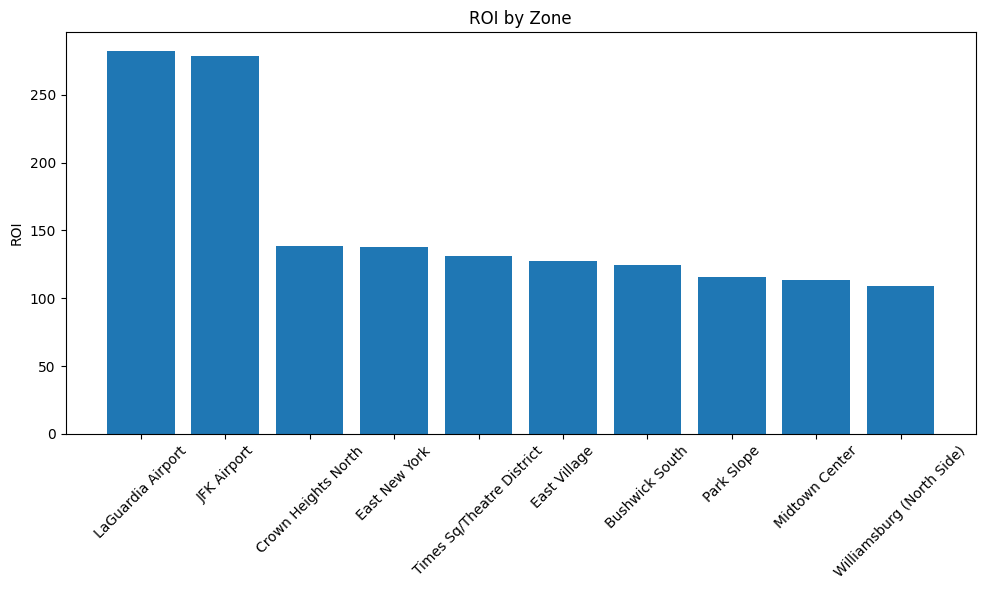

In [140]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(final_named['Zone_Name'], final_named['ROI'])
plt.xticks(rotation=45)
plt.title("ROI by Zone")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

### ROI Heatmap

<Axes: >

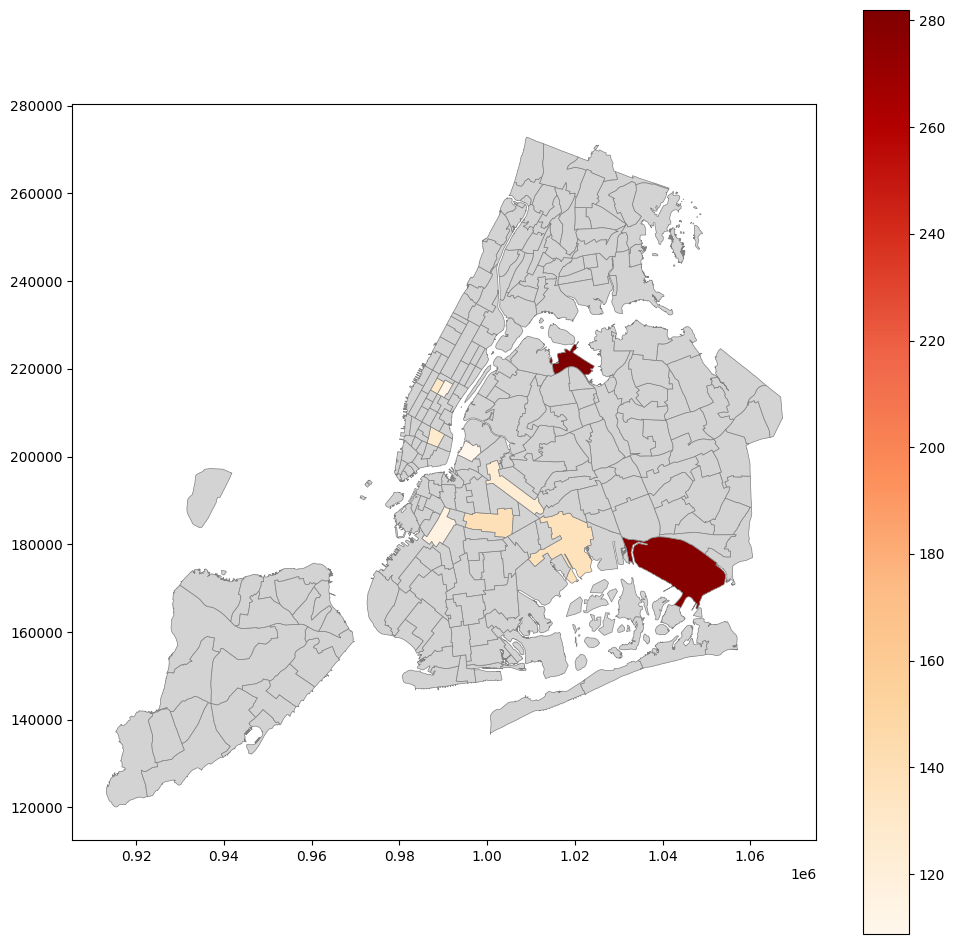

In [141]:
map_df = gdf.merge(
    final_named[['zone_id', 'Zone_Name', 'ROI', 'profit']],
    left_on='LocationID',
    right_on='zone_id',
    how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

map_df.plot(
    column='ROI',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='gray',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "Not in Top 10 Zones"
    },
    ax=ax
)

Adding labels

In [142]:
top10_map = map_df[map_df['ROI'].notna()]

for _, row in top10_map.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row['Zone_Name'],   # use zone name
        fontsize=7,
        ha='center'
    )

ax.set_title("Robotaxi ROI Heat Map by NYC Taxi Zone", fontsize=16)
ax.axis('off')

plt.show()

## Export dataset NYC_ZoneHour_ROI_Model_Dataset.csv

Apply same pricing logic to FULL dataset (not just top_df)

In [143]:
demand_df['demand_factor'] = demand_df['predicted_trips'] / demand_df['predicted_trips'].mean()


### Demand factor

In [144]:
demand_df['demand_factor'] = demand_df['predicted_trips'] / demand_df['predicted_trips'].mean()


### Dynamic pricing

In [145]:
demand_df['price_per_mile'] = BASE_PRICE_PER_MILE * (
    1 + 0.2 * (demand_df['demand_factor'] - 1)
)

### Revenue

In [146]:
demand_df['revenue'] = (
    demand_df['predicted_trips'] *
    demand_df['avg_distance'] *
    demand_df['price_per_mile']
)

### Cost

In [147]:
demand_df['cost'] = (
    demand_df['predicted_trips'] *
    demand_df['avg_distance'] *
    COST_PER_MILE
)

### Profit

In [148]:
demand_df['profit'] = demand_df['revenue'] - demand_df['cost']

### ROI

In [149]:
demand_df['ROI'] = demand_df['profit'] / demand_df['cost']

print(demand_df.head())

   PULocationID  hour  trips  avg_distance   avg_fare  avg_driver_pay  zone  \
0             2    11      1     18.490000  51.370000       58.480000     2   
1             2    20      1      3.370000  19.540000       14.250000     2   
2             3     0     29      3.923793  15.187241       14.063448     3   
3             3     1     17      6.480118  25.540000       19.854118     3   
4             3     2      6      2.415000  13.146667       10.438333     3   

   predicted_trips  demand_factor  price_per_mile     revenue        cost  \
0         0.000000       0.000000        2.000000    0.000000    0.000000   
1        37.021460       0.438428        2.219214  276.874266  149.714783   
2        11.684774       0.138377        2.069189   94.869473   55.018361   
3         3.506742       0.041529        2.020764   45.920053   27.268921   
4        26.366753       0.312249        2.156125  137.292757   76.410851   

       profit       ROI  
0    0.000000       NaN  
1  127.159

### CSV Export

In [150]:
demand_df.to_csv("NYC_ZoneHour_ROI_Model_Dataset.csv", index=False)

### Download

In [151]:
from google.colab import files
files.download("NYC_ZoneHour_ROI_Model_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Summary

This part converts predicted mobility demand into a business decision framework. A regression model estimates trips at the zone-hour level, after which revenue, cost, profit, and ROI are calculated under defined operating assumptions. This allows the project to move from social-need identification to financially grounded deployment strategy.